<a href="https://colab.research.google.com/github/orianadienta/Weather-based-Agricultural-Commodity-Price-Prediction/blob/main/Price_Prediction_With_Weather_ML_C_9ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA**

## Missing Value Checking

In [ ]:
df = pd.read_csv('data_gabungan_agri_cuaca.csv')
print(df.isnull().sum())

tanggal                          0
suhu_max_c                       0
suhu_min_c                       0
suhu_mean_c                      0
curah_hujan_mm                   0
hujan_mm                         0
jam_hujan                        0
kecepatan_angin_max_kmh          0
kencang_angin_kmh                0
kelembapan_max_pct               0
kelembapan_min_pct               0
durasi_sinar_matahari_detik      0
kode_cuaca_wmo                   0
durasi_sinar_matahari_jam        0
Cabe/Lombok Keriting           326
Cabe/Lombok Merah Besar        326
Cabe/Lombok Rawit              326
Sayuran Bayam                  326
Sayuran Kacang Panjang         326
Sayuran Kangkung               326
Sayuran Sawi                   326
dtype: int64


##

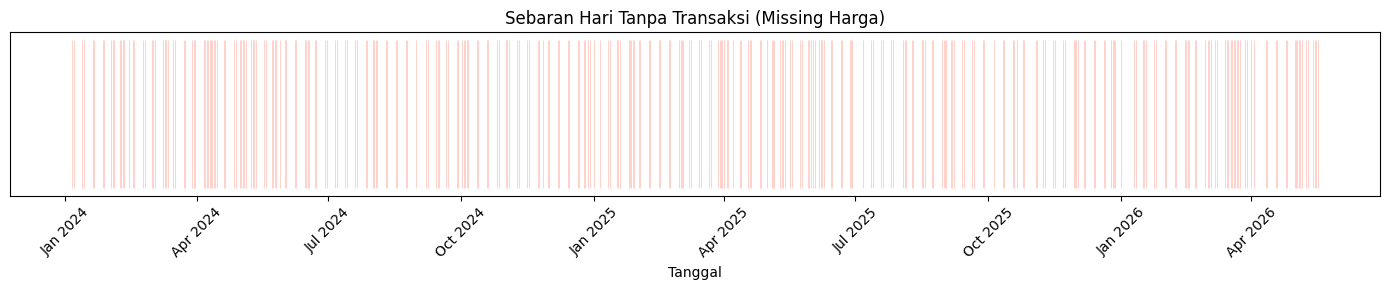

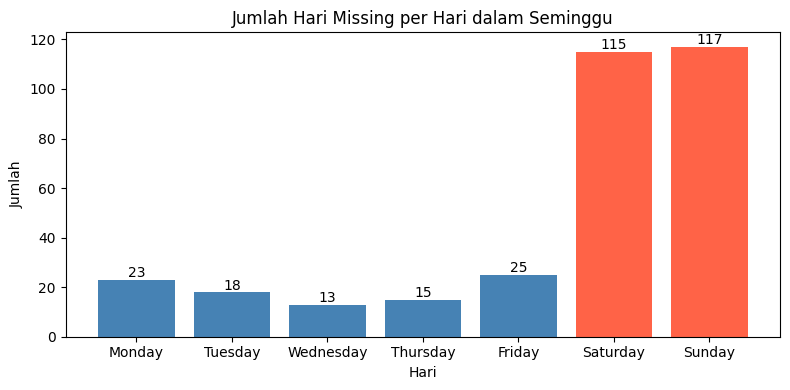

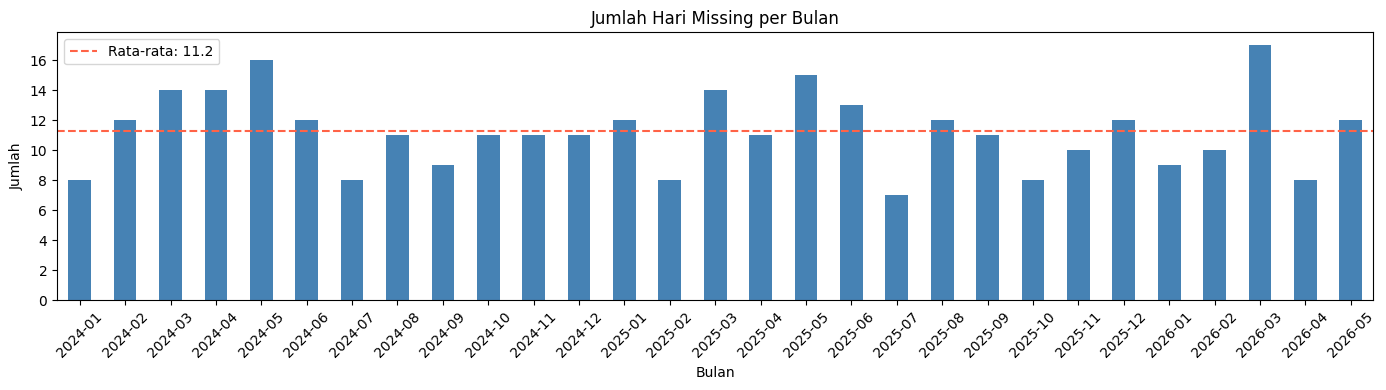

Total missing: 326 hari dari 872 hari (37.4%)

Missing per hari dalam seminggu:
nama_hari
Monday        23
Tuesday       18
Wednesday     13
Thursday      15
Friday        25
Saturday     115
Sunday       117


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('data_gabungan_agri_cuaca.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])

harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']

# Missing value marking
df['is_missing'] = df[harga_cols[0]].isna()

# Distribution of missing value
fig, ax = plt.subplots(figsize=(14, 3))
missing_dates = df[df['is_missing']]['tanggal']
ax.vlines(missing_dates, 0, 1, color='tomato', alpha=0.4, linewidth=0.5)
ax.set_title('Distribution of Days Without Price Data')
ax.set_xlabel('Tanggal')
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_pattern_timeline.png', dpi=150)
plt.show()

# Missing per days
df['nama_hari'] = df['tanggal'].dt.day_name()
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
missing_per_hari = df[df['is_missing']]['nama_hari'].value_counts().reindex(hari_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(missing_per_hari.index, missing_per_hari.values,
              color=['steelblue']*5 + ['tomato', 'tomato'])
ax.set_title('Jumlah Hari Missing per Hari dalam Seminggu')
ax.set_xlabel('Hari')
ax.set_ylabel('Jumlah')
for bar, val in zip(bars, missing_per_hari.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('missing_per_hari.png', dpi=150)
plt.show()

# Missing per month
df['bulan'] = df['tanggal'].dt.to_period('M')
missing_per_bulan = df[df['is_missing']].groupby('bulan').size()

fig, ax = plt.subplots(figsize=(14, 4))
missing_per_bulan.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Jumlah Hari Missing per Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah')
ax.axhline(y=missing_per_bulan.mean(), color='tomato', linestyle='--', label=f'Rata-rata: {missing_per_bulan.mean():.1f}')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_per_bulan.png', dpi=150)
plt.show()

print(f"Total missing: {df['is_missing'].sum()} hari dari {len(df)} hari ({df['is_missing'].mean()*100:.1f}%)")
print(f"\nMissing per hari dalam seminggu:")
print(missing_per_hari.to_string())

# **PREPROCESSING**

## 1. Imputation

In [ ]:
import pandas as pd
df_merged = pd.read_csv('data_gabungan_agri_cuaca.csv')

# Imputation using forward fill
harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']

df_merged[harga_cols] = df_merged[harga_cols].ffill()
df_merged.to_csv('data_gabungan_fix.csv', index=False)

## 2. Heatmap

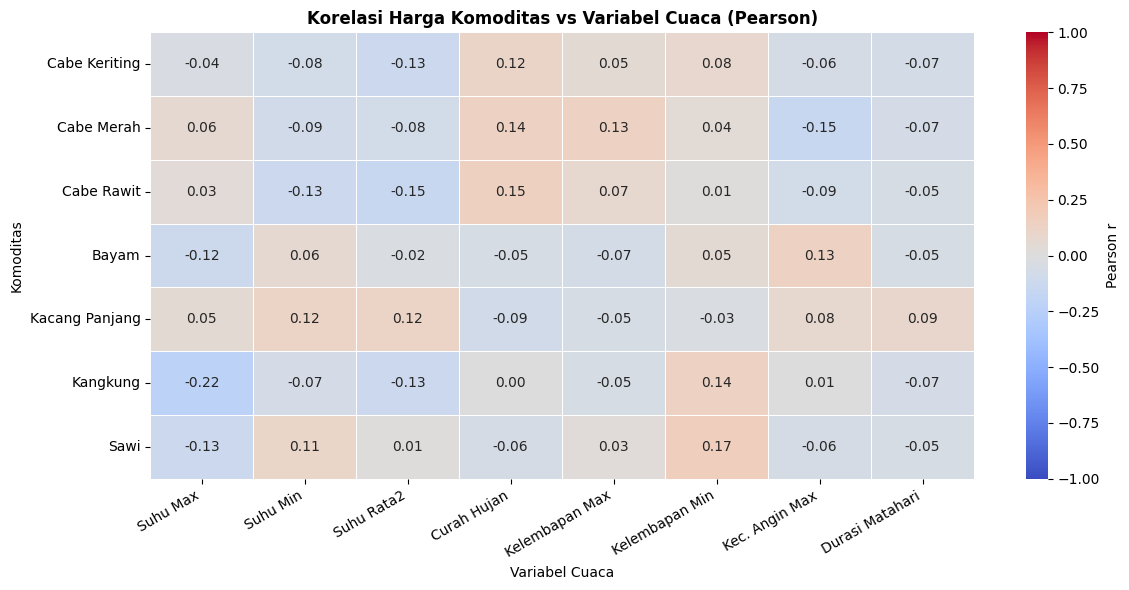

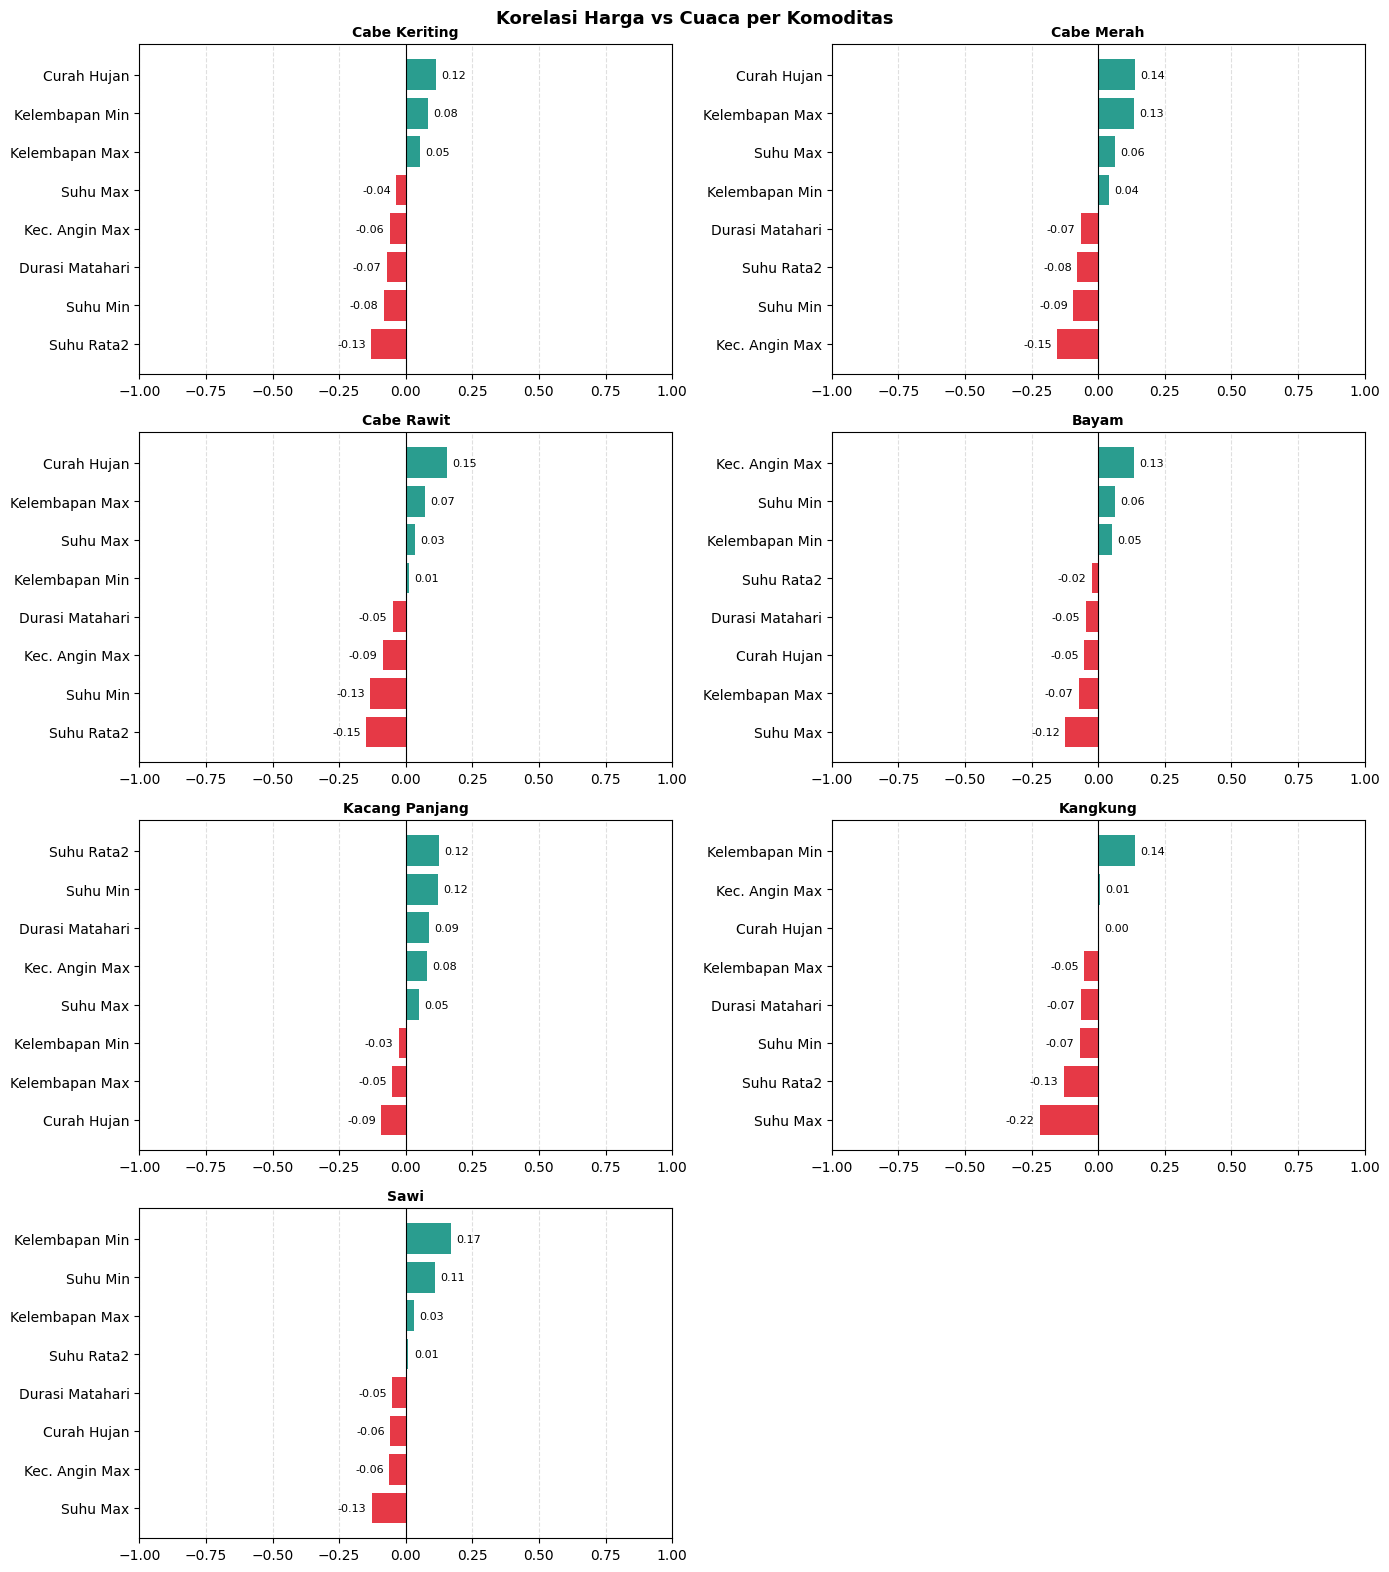

Variabel cuaca paling berkorelasi per komoditas:
  Cabe Keriting        → Suhu Rata2 (r = -0.129)
  Cabe Merah           → Kec. Angin Max (r = -0.154)
  Cabe Rawit           → Curah Hujan (r = 0.155)
  Bayam                → Kec. Angin Max (r = 0.135)
  Kacang Panjang       → Suhu Rata2 (r = 0.124)
  Kangkung             → Suhu Max (r = -0.220)
  Sawi                 → Kelembapan Min (r = 0.170)


In [ ]:
df = pd.read_csv('data_gabungan_fix.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').set_index('tanggal')

harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']
cuaca_cols = ['suhu_max_c', 'suhu_min_c', 'suhu_mean_c', 'curah_hujan_mm',
              'kelembapan_max_pct', 'kelembapan_min_pct', 'kecepatan_angin_max_kmh',
              'durasi_sinar_matahari_jam']

df[harga_cols] = df[harga_cols].ffill()

label_harga = {
    'Cabe/Lombok Keriting': 'Cabe Keriting',
    'Cabe/Lombok Merah Besar': 'Cabe Merah',
    'Cabe/Lombok Rawit': 'Cabe Rawit',
    'Sayuran Bayam': 'Bayam',
    'Sayuran Kacang Panjang': 'Kacang Panjang',
    'Sayuran Kangkung': 'Kangkung',
    'Sayuran Sawi': 'Sawi'
}
label_cuaca = {
    'suhu_max_c': 'Suhu Max',
    'suhu_min_c': 'Suhu Min',
    'suhu_mean_c': 'Suhu Rata2',
    'curah_hujan_mm': 'Curah Hujan',
    'kelembapan_max_pct': 'Kelembapan Max',
    'kelembapan_min_pct': 'Kelembapan Min',
    'kecepatan_angin_max_kmh': 'Kec. Angin Max',
    'durasi_sinar_matahari_jam': 'Durasi Matahari'
}

df_harga = df[harga_cols].rename(columns=label_harga)
df_cuaca = df[cuaca_cols].rename(columns=label_cuaca)

# --- Plot 1: Heatmap korelasi harga vs cuaca ---
corr_matrix = pd.concat([df_harga, df_cuaca], axis=1).corr()
corr_harga_cuaca = corr_matrix.loc[list(label_harga.values()), list(label_cuaca.values())]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_harga_cuaca, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Korelasi Harga Komoditas vs Variabel Cuaca (Pearson)', fontweight='bold', fontsize=12)
ax.set_xlabel('Variabel Cuaca')
ax.set_ylabel('Komoditas')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('corr_harga_cuaca_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Bar chart korelasi per komoditas (ranked) ---
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, komoditas in enumerate(label_harga.values()):
    row = corr_harga_cuaca.loc[komoditas].sort_values()
    colors = ['#e63946' if v < 0 else '#2a9d8f' for v in row.values]
    axes[idx].barh(row.index, row.values, color=colors)
    axes[idx].axvline(0, color='black', linewidth=0.8)
    axes[idx].set_title(komoditas, fontweight='bold', fontsize=10)
    axes[idx].set_xlim(-1, 1)
    axes[idx].grid(axis='x', linestyle='--', alpha=0.4)
    for i, (val, label) in enumerate(zip(row.values, row.index)):
        axes[idx].text(val + (0.02 if val >= 0 else -0.02), i,
                       f'{val:.2f}', va='center',
                       ha='left' if val >= 0 else 'right', fontsize=8)

# Hapus subplot kosong (ke-8)
fig.delaxes(axes[-1])

fig.suptitle('Korelasi Harga vs Cuaca per Komoditas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('corr_harga_cuaca_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print variabel cuaca paling berpengaruh per komoditas ---
print("Variabel cuaca paling berkorelasi per komoditas:")
for komoditas in label_harga.values():
    top = corr_harga_cuaca.loc[komoditas].abs().idxmax()
    val = corr_harga_cuaca.loc[komoditas, top]
    print(f"  {komoditas:20s} → {top} (r = {val:.3f})")

In [ ]:
df.describe()

,suhu_max_c,suhu_min_c,suhu_mean_c,curah_hujan_mm,hujan_mm,jam_hujan,kecepatan_angin_max_kmh,kencang_angin_kmh,kelembapan_max_pct,kelembapan_min_pct,durasi_sinar_matahari_detik,kode_cuaca_wmo,durasi_sinar_matahari_jam,Cabe/Lombok Keriting,Cabe/Lombok Merah Besar,Cabe/Lombok Rawit,Sayuran Bayam,Sayuran Kacang Panjang,Sayuran Kangkung,Sayuran Sawi
count,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.00000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000
mean,29.769725,24.529931,26.908257,9.658945,9.658945,10.673165,12.81617,29.802408,96.331697,71.628305,32032.976365,58.846330,8.897959,54128.153670,53409.116972,59145.928899,9503.727064,10821.674312,8216.456422,11592.029817
std,1.229638,0.782595,0.762090,9.932428,9.932428,4.981234,2.79602,5.675579,3.208327,6.155356,10327.478483,8.716969,2.868687,14534.643927,13211.462816,20698.123235,3681.695247,3395.841543,2103.611064,3628.235854
min,25.500000,22.600000,24.200000,0.000000,0.000000,0.000000,7.00000,16.900000,78.780716,47.957360,0.000000,1.000000,0.000000,25000.000000,25000.000000,29000.000000,3000.000000,5000.000000,3000.000000,5000.000000
25%,29.000000,24.000000,26.400000,2.275000,2.275000,7.000000,10.90000,25.900000,95.045775,67.874822,26775.624500,53.000000,7.440000,43000.000000,43000.000000,40000.000000,7000.000000,10000.000000,6375.000000,10000.000000
50%,29.800000,24.500000,26.900000,6.900000,6.900000,10.000000,12.40000,29.200000,97.052060,72.024840,35692.244500,63.000000,9.915000,52000.000000,55000.000000,58000.000000,9000.000000,10000.000000,9000.000000,10000.000000
75%,30.500000,25.000000,27.500000,13.925000,13.925000,14.000000,14.20000,32.800000,98.232955,75.845810,39740.701250,63.000000,11.040000,62500.000000,62000.000000,73000.000000,11000.000000,12000.000000,10000.000000,12000.000000
max,33.200000,27.000000,28.800000,95.700000,95.700000,24.000000,25.00000,57.200000,100.000000,94.500300,43200.000000,65.000000,12.000000,97000.000000,90000.000000,122500.000000,26000.000000,25000.000000,12000.000000,26000.000000


## 2. Parsing Date Features and Feature Selection

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Weather and price dataset.csv')
print(df.dtypes)

date                          object
max_temperature_c            float64
min_temperature_c            float64
mean_temperature_c           float64
rainfall_mm                  float64
precipitation_mm             float64
rain_duration_hours            int64
max_wind_speed_kmh           float64
wind_speed_kmh               float64
max_humidity_pct             float64
min_humidity_pct             float64
sunshine_duration_seconds    float64
wmo_weather_code               int64
sunshine_duration_hours      float64
Curly Chili Pepper             int64
Large Red Chili Pepper         int64
Bird's Eye Chili Pepper        int64
Spinach                        int64
Long Bean                      int64
Water Spinach                  int64
Mustard Greens                 int64
dtype: object


In [ ]:
# Parsing Date Feature
df['date'] = pd.to_datetime(df['date'])

df = df.set_index('date')
df = df.sort_index()

print(df.index.dtype)
print(df.head())

df = df.drop(columns=[
    'precipitation_mm',
    'sunshine_duration_seconds',
    'wmo_weather_code',
    'rain_duration_hours',
    'max_wind_speed_kmh',
    'max_temperature_c',
    'min_temperature_c'
])

print(df.shape)
print(df.columns.tolist())

df_raw = df.copy()
print(f"df_raw shape: {df_raw.shape}")
print(f"df_raw columns: {df_raw.columns.tolist()}")

datetime64[ns]
            max_temperature_c  min_temperature_c  mean_temperature_c  \
date                                                                   
2024-01-01               29.8               24.4                26.4   
2024-01-02               28.0               23.3                25.8   
2024-01-03               31.0               24.0                26.5   
2024-01-04               31.2               23.4                27.2   
2024-01-05               27.8               23.8                25.5   

            rainfall_mm  precipitation_mm  rain_duration_hours  \
date                                                             
2024-01-01          7.1               7.1                   12   
2024-01-02         16.1              16.1                   16   
2024-01-03          7.8               7.8                    9   
2024-01-04         13.3              13.3                   13   
2024-01-05         14.8              14.8                   19   

            max_w

# Loop N Untuk Modelling dan Split Data

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from autogluon.tabular import TabularPredictor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

price_cols = [
    'Curly Chili Pepper',
    'Large Red Chili Pepper',
    "Bird's Eye Chili Pepper",
    'Spinach',
    'Long Bean',
    'Water Spinach',
    'Mustard Greens',
]

weather_cols = [
    'rainfall_mm',
    'mean_temperature_c',
    'min_humidity_pct',
    'wind_speed_kmh',
    'sunshine_duration_hours',
]

all_xgb_results = []
all_ag_results  = []

all_fi = []  # ← tambah ini sebelum for N in range(1, 8)

for N in range(1, 8):   # N=1 s/d N=7
    print(f"\n{'='*60}")
    print(f"  N = {N}  (fitur H-1 sampai H-{N})")
    print(f"{'='*60}")

    # ── Feature engineering (selalu dari df_raw) ──────────────
    df = df_raw.copy()

    for col in price_cols:
        for n in range(1, N + 1):
            df[f'{col}_lag{n}'] = df[col].shift(n)

    for col in weather_cols:
        for n in range(1, N + 1):
            df[f'{col}_lag{n}'] = df[col].shift(n)

    target_cols = price_cols
    for col in target_cols:
        df[f'{col}_target_h1'] = df[col].shift(-1)

    df = df.dropna()

    # ── Split (dihitung ulang tiap N) ─────────────────────────
    split_idx = int(len(df) * 0.8)
    train = df.iloc[:split_idx].reset_index()
    test  = df.iloc[split_idx:].reset_index()

    target_h1_cols = [f'{c}_target_h1' for c in target_cols]

    feature_cols = [
        c for c in train.columns
        if c not in target_cols + target_h1_cols + ['date']
    ]

    print(f"Shape setelah dropna : {df.shape}")
    print(f"Train: {train['date'].min()} → {train['date'].max()} ({len(train)} baris)")
    print(f"Test : {test['date'].min()}  → {test['date'].max()}  ({len(test)} baris)")
    print(f"Jumlah fitur         : {len(feature_cols)}")

    # ── XGBoost ───────────────────────────────────────────────
    print(f"\n--- XGBoost N={N} ---")
    for target in target_cols:
        target_h1 = f'{target}_target_h1'

        model = XGBRegressor(random_state=42)
        model.fit(train[feature_cols], train[target_h1])
        y_pred = model.predict(test[feature_cols])
        y_test = test[target_h1]

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100

        all_xgb_results.append({
            'N': N, 'Commodity': target,
            'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape,
        })
        print(f"  {target:30s}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

    # ── AutoGluon ─────────────────────────────────────────────
    print(f"\n--- AutoGluon N={N} ---")
    for target in target_cols:
        target_h1 = f'{target}_target_h1'

        cols_to_drop = (
            [c for c in target_h1_cols if c != target_h1]
            + target_cols
            + ['date']
        )
        train_input = train.drop(columns=cols_to_drop)
        test_input  = test.drop(columns=cols_to_drop)

        model_name = (
            target.replace("/", "_").replace(" ", "_").replace("'", "")
        )

        predictor = TabularPredictor(
            label=target_h1,
            path=f"models/N{N}_{model_name}_h1",   # ← N di path, nggak overwrite
            eval_metric="mean_absolute_error",
            problem_type="regression",
        )
        predictor.fit(train_input, time_limit=300, presets="medium_quality")

        y_pred = predictor.predict(test_input.drop(columns=[target_h1]))
        y_test = test_input[target_h1]

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100

        all_ag_results.append({
            'N': N, 'Commodity': target,
            'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape,
        })
        print(f"  {target:30s}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

xgb_results_df = pd.DataFrame(all_xgb_results)
ag_results_df  = pd.DataFrame(all_ag_results)
print("\n✅ Semua eksperimen selesai!")


  N = 1  (fitur H-1 sampai H-1)
Shape setelah dropna : (870, 32)
Train: 2024-01-02 00:00:00 → 2025-11-27 00:00:00 (696 baris)
Test : 2025-11-28 00:00:00  → 2026-05-20 00:00:00  (174 baris)
Jumlah fitur         : 18

--- XGBoost N=1 ---
  Curly Chili Pepper              MAE=3816.24  RMSE=5329.04  MAPE=8.34%
  Large Red Chili Pepper          MAE=5297.62  RMSE=7276.78  MAPE=9.42%
  Bird's Eye Chili Pepper         MAE=11519.73  RMSE=15081.72  MAPE=16.60%
  Spinach                         MAE=705.07  RMSE=988.53  MAPE=6.67%
  Long Bean                       MAE=384.38  RMSE=517.19  MAPE=3.84%
  Water Spinach                   MAE=414.56  RMSE=738.60  MAPE=5.33%


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.92 GB / 12.67 GB (86.2%)
Disk Space Avail:   86.36 GB / 107.72 GB (80.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'


  Mustard Greens                  MAE=613.55  RMSE=787.78  MAPE=6.14%

--- AutoGluon N=1 ---


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models/N1_Curly_Chili_Pepper_h1"
Train Data Rows:    696
Train Data Columns: 18
Label Column:       Curly Chili Pepper_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11182.90 MB
	Train Data (Original)  Memory Usage: 0.10 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('floa

  Curly Chili Pepper              MAE=3338.59  RMSE=4479.01  MAPE=7.43%


...

Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models/N1_Spinach_h1"
Train Data Rows:    696
Train Data Columns: 18
Label Column:       Spinach_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11126.87 MB
	Train Data (Original)  Memory Usage: 0.10 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('float', []) : 18 | ['mean_

  Spinach                         MAE=629.91  RMSE=806.50  MAPE=5.93%


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models/N1_Long_Bean_h1"
Train Data Rows:    696
Train Data Columns: 18
Label Column:       Long Bean_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11103.92 MB
	Train Data (Original)  Memory Usage: 0.10 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('float', []) : 18 | ['m

[1000]	valid_set's l1: 1469.88
[2000]	valid_set's l1: 1469.88
[3000]	valid_set's l1: 1469.88
[4000]	valid_set's l1: 1469.88
[5000]	valid_set's l1: 1469.88
[6000]	valid_set's l1: 1469.88
[7000]	valid_set's l1: 1469.88
[8000]	valid_set's l1: 1469.88
[9000]	valid_set's l1: 1469.88


KeyboardInterrupt: 

## Evaluasi

In [ ]:
# Rata-rata metrik per N
xgb_summary = xgb_results_df.groupby('N')[['MAE', 'RMSE', 'MAPE (%)']].mean().round(2)
ag_summary  = ag_results_df.groupby('N')[['MAE', 'RMSE', 'MAPE (%)']].mean().round(2)

print("=== XGBoost: rata-rata per N ===")
print(xgb_summary)

print("\n=== AutoGluon: rata-rata per N ===")
print(ag_summary)

# N terbaik berdasarkan MAE rata-rata
best_xgb_N = xgb_summary['MAE'].idxmin()
best_ag_N  = ag_summary['MAE'].idxmin()

print(f"\n→ Best N XGBoost  : N={best_xgb_N}  (MAE={xgb_summary.loc[best_xgb_N, 'MAE']})")
print(f"→ Best N AutoGluon: N={best_ag_N}  (MAE={ag_summary.loc[best_ag_N, 'MAE']})")

=== XGBoost: rata-rata per N ===
       MAE     RMSE  MAPE (%)
N                            
1  3250.16  4388.52      8.05
2  3009.98  4031.94      8.70
3  2507.81  3382.24      7.67
4  2551.52  3456.39      7.87
5  2142.53  3079.59      6.16
6  2337.70  3296.19      6.52
7  2306.67  3250.27      6.95

=== AutoGluon: rata-rata per N ===
       MAE     RMSE  MAPE (%)
N                            
1  2015.70  2858.54      5.90
2  1885.05  2702.43      5.64
3  2245.54  3019.09      7.29
4  1908.79  2769.70      6.41
5  2049.20  2970.72      6.75
6  1926.12  2705.99      5.96
7  1953.14  2764.92      6.09

→ Best N XGBoost  : N=5  (MAE=2142.53)
→ Best N AutoGluon: N=2  (MAE=1885.05)


In [ ]:
# Rata-rata metrik per N
xgb_summary = xgb_results_df.groupby('N')[['MAE', 'RMSE', 'MAPE (%)']].mean().round(2)
ag_summary  = ag_results_df.groupby('N')[['MAE', 'RMSE', 'MAPE (%)']].mean().round(2)

print("=== XGBoost: rata-rata per N ===")
print(xgb_summary)

print("\n=== AutoGluon: rata-rata per N ===")
print(ag_summary)

# N terbaik berdasarkan RMSE rata-rata
best_xgb_N = xgb_summary['RMSE'].idxmin()
best_ag_N  = ag_summary['RMSE'].idxmin()

print(f"\n→ Best N XGBoost  : N={best_xgb_N}  (RMSE={xgb_summary.loc[best_xgb_N, 'RMSE']})")
print(f"→ Best N AutoGluon: N={best_ag_N}  (RMSE={ag_summary.loc[best_ag_N, 'RMSE']})")

=== XGBoost: rata-rata per N ===
       MAE     RMSE  MAPE (%)
N                            
1  3250.16  4388.52      8.05
2  3009.98  4031.94      8.70
3  2507.81  3382.24      7.67
4  2551.52  3456.39      7.87
5  2142.53  3079.59      6.16
6  2337.70  3296.19      6.52
7  2306.67  3250.27      6.95

=== AutoGluon: rata-rata per N ===
       MAE     RMSE  MAPE (%)
N                            
1  2015.70  2858.54      5.90
2  1885.05  2702.43      5.64
3  2245.54  3019.09      7.29
4  1908.79  2769.70      6.41
5  2049.20  2970.72      6.75
6  1926.12  2705.99      5.96
7  1953.14  2764.92      6.09

→ Best N XGBoost  : N=5  (RMSE=3079.59)
→ Best N AutoGluon: N=2  (RMSE=2702.43)


In [ ]:
short_names = {
    'Curly Chili Pepper': 'Curly Chili',
    'Large Red Chili Pepper': 'Large Red Chili',
    "Bird's Eye Chili Pepper": "Bird's Eye Chili",
    'Spinach': 'Spinach',
    'Long Bean': 'Long Bean',
    'Water Spinach': 'Water Spinach',
    'Mustard Greens': 'Mustard Greens'
}

metrics = ['MAE', 'RMSE', 'MAPE (%)']
col_names = [short_names[t] for t in price_cols] + ['Average']

for n in range(1, 8):
    rows = []
    idx = []

    xgb_n = xgb_results_df[xgb_results_df['N'] == n].set_index('Commodity')
    ag_n  = ag_results_df[ag_results_df['N'] == n].set_index('Commodity')

    for source_name, source_df in [('XGBoost', xgb_n), ('AutoGluon', ag_n)]:
        for met in metrics:
            row_vals = [round(source_df.loc[t, met], 2) for t in price_cols]
            avg = round(np.nanmean(row_vals), 2)
            rows.append(row_vals + [avg])
            idx.append((source_name, met))

    df_n = pd.DataFrame(
        rows,
        index=pd.MultiIndex.from_tuples(idx, names=['Model', 'Metric']),
        columns=col_names
    )

    display(
        df_n.style
        .background_gradient(cmap='RdYlGn_r', axis=1, subset=pd.IndexSlice[:, col_names])
        .format('{:,.2f}')
        .set_caption(f'N={n} (H-1 s/d H-{n}) — XGBoost vs AutoGluon')
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-weight', 'bold'), ('font-size', '13px'), ('margin-bottom', '8px')]
        }])
    )

## Leaderboard

In [ ]:
for target in price_cols:
    model_name = target.replace("/", "_").replace(" ", "_").replace("'", "")
    predictor = TabularPredictor.load(f"models/N2_{model_name}_h1")

    lb = predictor.leaderboard(silent=True)[['model', 'score_val']].copy()
    lb['score_val'] = (-lb['score_val']).round(2)
    lb.columns = ['Model', 'Val MAE']
    lb = lb.reset_index(drop=True)
    lb.index += 1

    display(
        lb.style
        .background_gradient(cmap='RdYlGn_r', subset=['Val MAE'])
        .format({'Val MAE': '{:,.2f}'})
        .set_caption(f'AutoGluon Leaderboard N=2 — {target}')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px'), ('margin-bottom', '8px')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]},
        ])
    )

    best_model = lb.loc[lb['Val MAE'].idxmin(), 'Model']
    print(f"✅ Best model: {best_model}\n")

,Model,Val MAE
1,WeightedEnsemble_L2,"4,080.91"
2,RandomForestMSE,"4,101.50"
3,ExtraTreesMSE,"4,330.07"
4,NeuralNetTorch,"4,503.43"
5,XGBoost,"4,611.35"
6,LightGBM,"4,728.61"
7,LightGBMXT,"4,739.57"
8,LightGBMLarge,"4,843.73"
9,NeuralNetFastAI,"5,210.86"


✅ Best model: WeightedEnsemble_L2



,Model,Val MAE
1,WeightedEnsemble_L2,"3,022.26"
2,ExtraTreesMSE,"3,281.55"
3,NeuralNetTorch,"3,413.90"
4,NeuralNetFastAI,"3,427.16"
5,LightGBM,"3,456.80"
6,LightGBMXT,"3,517.04"
7,RandomForestMSE,"3,558.88"
8,LightGBMLarge,"3,728.86"
9,XGBoost,"3,809.16"


✅ Best model: WeightedEnsemble_L2



,Model,Val MAE
1,WeightedEnsemble_L2,"5,329.19"
2,LightGBMXT,"5,674.48"
3,NeuralNetTorch,"5,815.55"
4,ExtraTreesMSE,"5,973.41"
5,RandomForestMSE,"6,246.94"
6,LightGBM,"6,330.13"
7,NeuralNetFastAI,"6,859.52"
8,XGBoost,"6,933.70"
9,LightGBMLarge,"7,269.24"


...

✅ Best model: WeightedEnsemble_L2



,Model,Val MAE
1,WeightedEnsemble_L2,417.02
2,RandomForestMSE,427.11
3,ExtraTreesMSE,433.51
4,NeuralNetTorch,457.57
5,LightGBMLarge,486.26
6,LightGBMXT,488.72
7,XGBoost,492.82
8,LightGBM,500.27
9,NeuralNetFastAI,548.84


✅ Best model: WeightedEnsemble_L2



,Model,Val MAE
1,WeightedEnsemble_L2,"1,165.64"
2,NeuralNetTorch,"1,216.81"
3,ExtraTreesMSE,"1,247.97"
4,RandomForestMSE,"1,286.64"
5,LightGBMXT,"1,315.55"
6,XGBoost,"1,316.23"
7,LightGBM,"1,331.85"
8,LightGBMLarge,"1,435.23"
9,NeuralNetFastAI,"1,554.84"


✅ Best model: WeightedEnsemble_L2



## Visualization Prediction vs Actual

XGBoost N=2 trained: Curly Chili Pepper ✓
XGBoost N=2 trained: Large Red Chili Pepper ✓
XGBoost N=2 trained: Bird's Eye Chili Pepper ✓
XGBoost N=2 trained: Spinach ✓
XGBoost N=2 trained: Long Bean ✓
XGBoost N=2 trained: Water Spinach ✓
XGBoost N=2 trained: Mustard Greens ✓


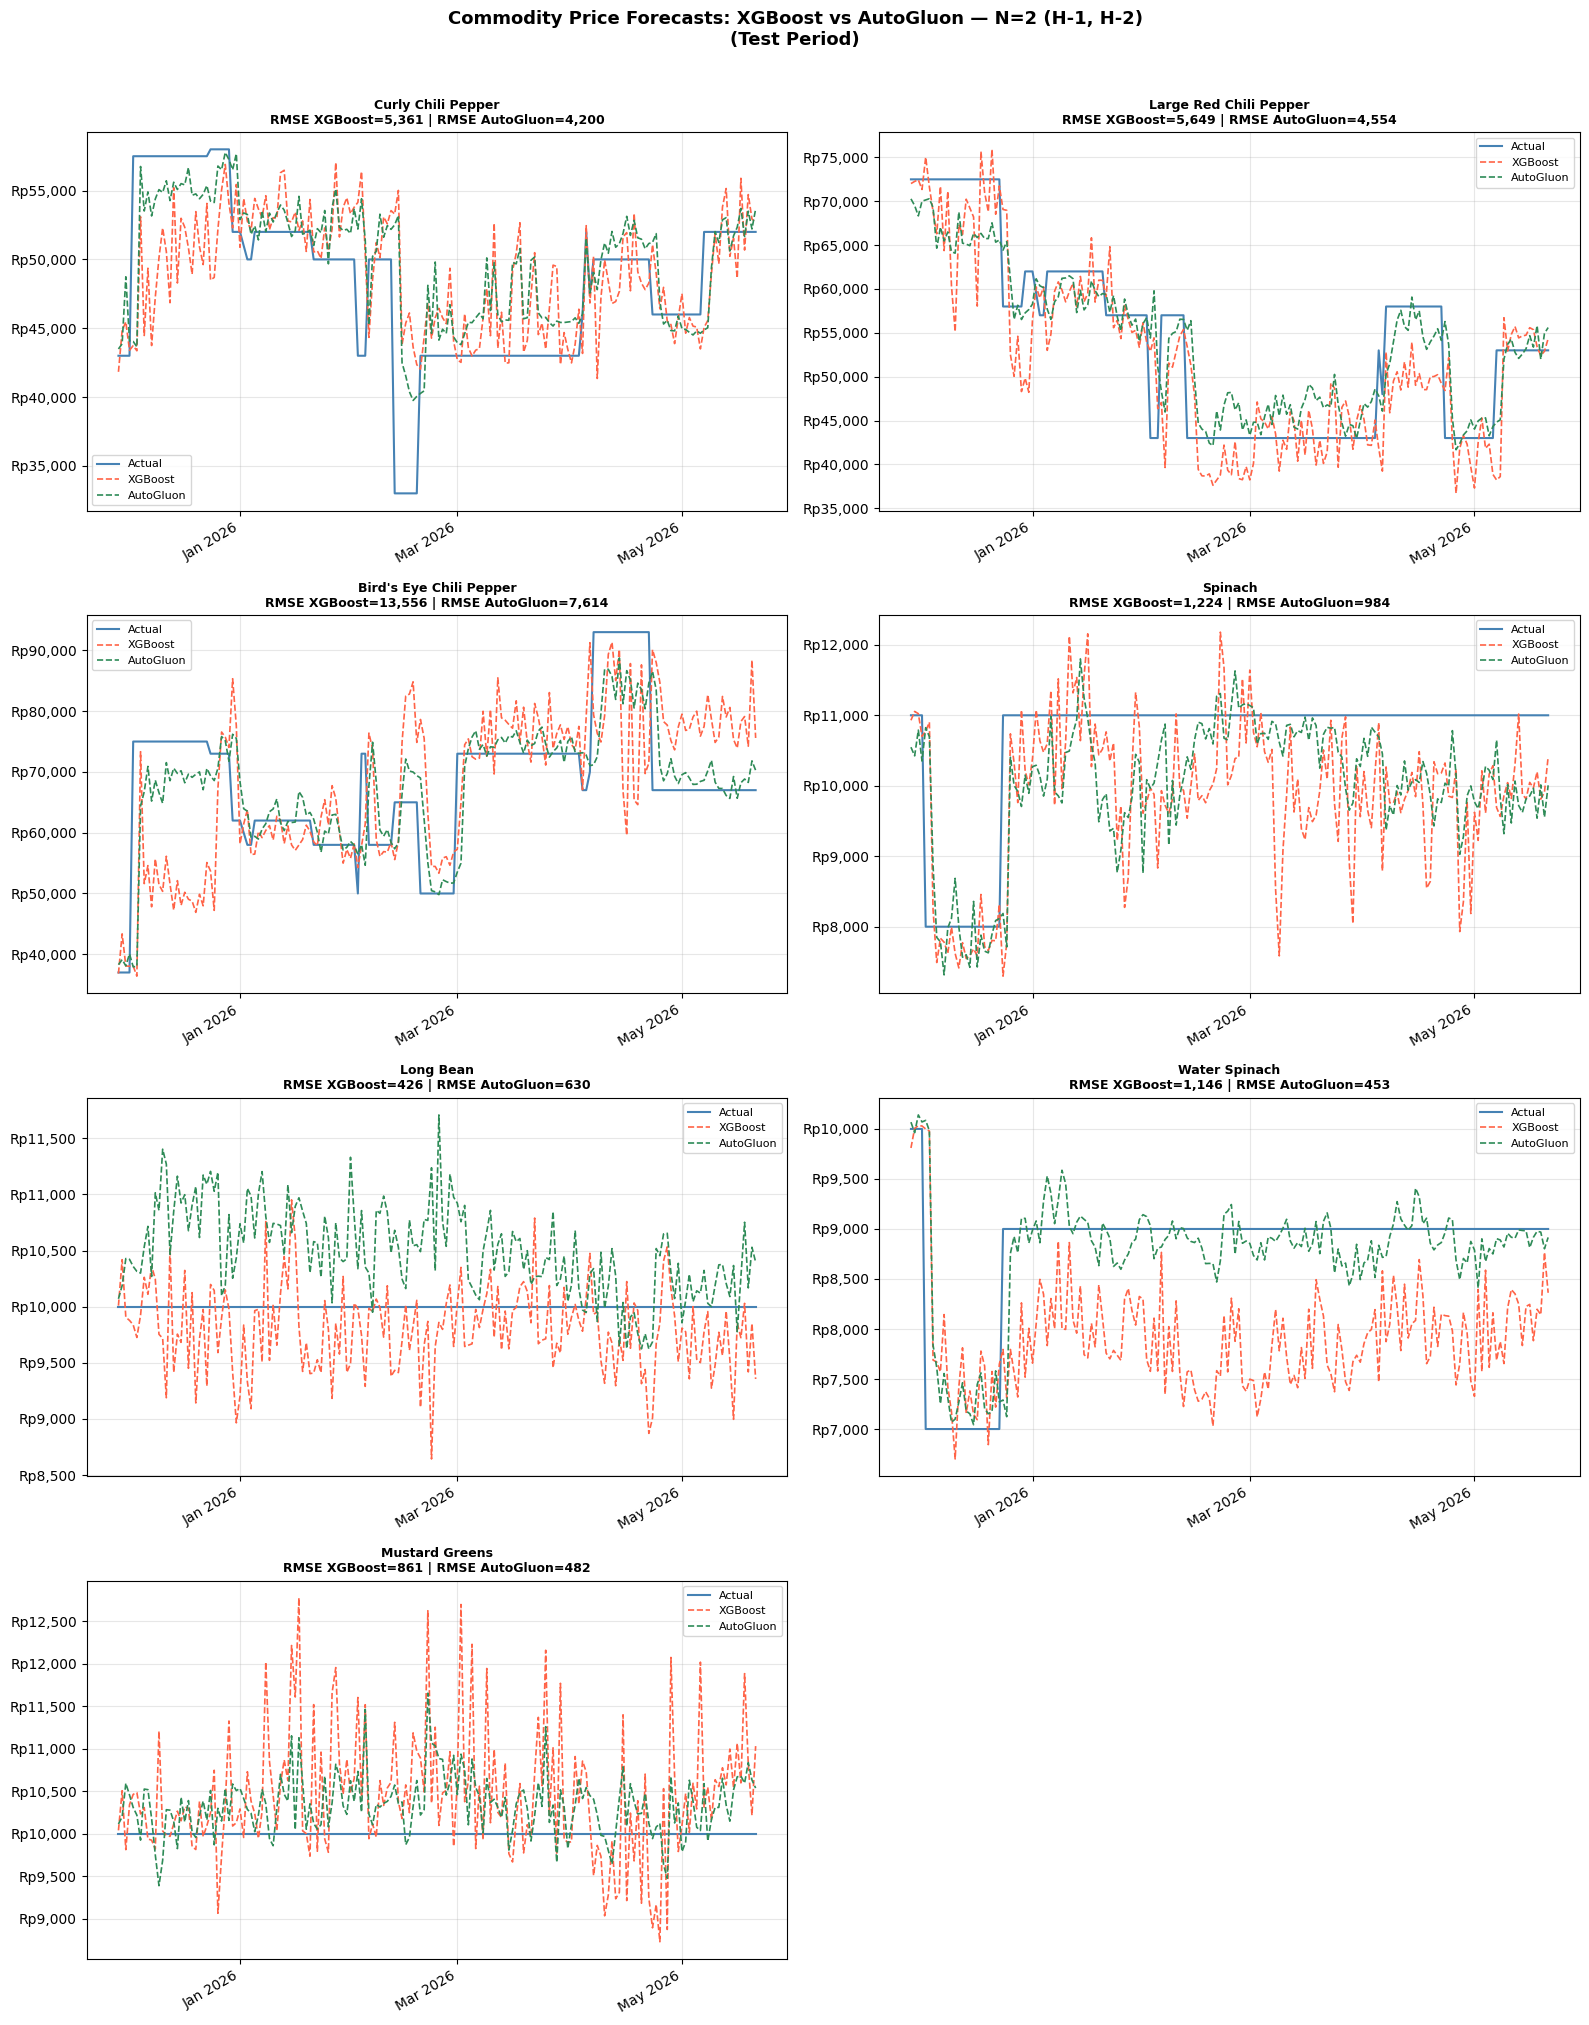

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

N = 2

# ── Rebuild dataset N=2 ───────────────────────────────────────
df = df_raw.copy()
for col in price_cols:
    for n in range(1, N + 1):
        df[f'{col}_lag{n}'] = df[col].shift(n)
for col in weather_cols:
    for n in range(1, N + 1):
        df[f'{col}_lag{n}'] = df[col].shift(n)
for col in price_cols:
    df[f'{col}_target_h1'] = df[col].shift(-1)
df = df.dropna()

split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].reset_index()
test  = df.iloc[split_idx:].reset_index()

target_h1_cols = [f'{c}_target_h1' for c in price_cols]
feature_cols = [
    c for c in train.columns
    if c not in price_cols + target_h1_cols + ['date']
]

# ── Retrain XGBoost N=2 ───────────────────────────────────────
xgb_models_n2 = {}
for target in price_cols:
    target_h1 = f'{target}_target_h1'
    model = XGBRegressor(random_state=42)
    model.fit(train[feature_cols], train[target_h1])
    xgb_models_n2[target] = model
    print(f"XGBoost N=2 trained: {target} ✓")

# ── Visualisasi ───────────────────────────────────────────────
dates = pd.to_datetime(test['date']) + pd.Timedelta(days=1)

xgb_n2 = xgb_results_df[xgb_results_df['N'] == N].set_index('Commodity')
ag_n2  = ag_results_df[ag_results_df['N'] == N].set_index('Commodity')

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, target in enumerate(price_cols):
    target_h1 = f'{target}_target_h1'
    ax = axes[i]

    actual   = test[target_h1].values
    pred_xgb = xgb_models_n2[target].predict(test[feature_cols])

    # Load AutoGluon N=2 dari disk
    model_name = target.replace("/", "_").replace(" ", "_").replace("'", "")
    predictor  = TabularPredictor.load(f"models/N2_{model_name}_h1")

    cols_to_drop = (
        [c for c in target_h1_cols if c != target_h1]
        + price_cols + ['date']
    )
    test_input = test.drop(columns=cols_to_drop)
    pred_ag = predictor.predict(test_input.drop(columns=[target_h1])).values

    ax.plot(dates, actual,   label='Actual',    color='steelblue', linewidth=1.5)
    ax.plot(dates, pred_xgb, label='XGBoost',   color='tomato',    linewidth=1.2, linestyle='--')
    ax.plot(dates, pred_ag,  label='AutoGluon', color='seagreen',  linewidth=1.2, linestyle='--')

    rmse_xgb = xgb_n2.loc[target, 'RMSE']
    rmse_ag  = ag_n2.loc[target, 'RMSE']

    ax.set_title(
        f"{target}\nRMSE XGBoost={rmse_xgb:,.0f} | RMSE AutoGluon={rmse_ag:,.0f}",
        fontsize=9, fontweight='bold'
    )

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle(
    'Commodity Price Forecasts: XGBoost vs AutoGluon — N=2 (H-1, H-2)\n(Test Period)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('predictions_vs_actual_N2.png', dpi=150, bbox_inches='tight')
plt.show()